In [11]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal , Annotated
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage , HumanMessage
import operator
from pydantic import BaseModel , Field
from langgraph.checkpoint.memory import MemorySaver

In [2]:
from langchain_core.messages import BaseMessage, HumanMessage


In [3]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage] , add_messages ]

In [4]:
load_dotenv()

True

In [5]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0, 
    max_tokens=None,
    timeout=None,
    max_retries=2,
) 


def chat_node(state: ChatState):


    #take user query  from state 
    messages = state['messages']
    # send to llm 
    response= llm.invoke(messages)

    # response store state 
    return {'messages':[response]}

    

In [12]:
checkpointer = MemorySaver()


graph = StateGraph(ChatState)

graph.add_node('chat_node' , chat_node)

graph.add_edge(START , 'chat_node')
graph.add_edge('chat_node' , END)

chatbot = graph.compile(checkpointer=checkpointer)




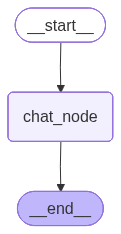

In [9]:
chatbot

In [8]:
initial_state = {
    'messages': [HumanMessage( content = 'What is the capital Of India')]


}
chatbot.invoke(initial_state)['messages'][-1].content


'The capital of India is **New Delhi**.'

In [ ]:
thread_id = '1'


while True:

    user_message = input('Type Here')

    print(user_message)

    if user_message.strip().lower() in ['exit' , 'quit' , 'bye']:
        break


    config = {'configurable': {'thread_id' : thread_id}}


    response = chatbot.invoke({'messages': [HumanMessage(content = user_message)]} , config = config)

    print('AI' , response['messages'][-1].content)

In [14]:
chatbot.get_state(config = config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is shivam', additional_kwargs={}, response_metadata={}, id='87014325-fc05-4e96-a833-6d79c03c02e6')]}, next=('chat_node',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e6e5a-5f40-6195-8000-d9c36c30d945'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-01-01T07:44:05.461594+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e6e5a-5f2f-67da-bfff-07de5f0b6e3e'}}, tasks=(PregelTask(id='0917cd8a-1c71-7cba-280d-3a6bc0b5d8eb', name='chat_node', path=('__pregel_pull', 'chat_node'), error='ChatGoogleGenerativeAIError("Error calling model \'gemini-2.5-flash\' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {\'error\': {\'code\': 429, \'message\': \'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits.